In [10]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
def f(x, y):
    return -2 * y * np.cos(x)

def exact_sol(x):
    return np.exp(-2 * np.sin(x))

x_start = 0
x_end = 10 * np.pi
y0 = 1

#step sizes
h_values = [0.01, 0.05] + list(np.arange(0.15, 1.05, 0.05))

results = []
avg_errors = []
errors_at_15 = []

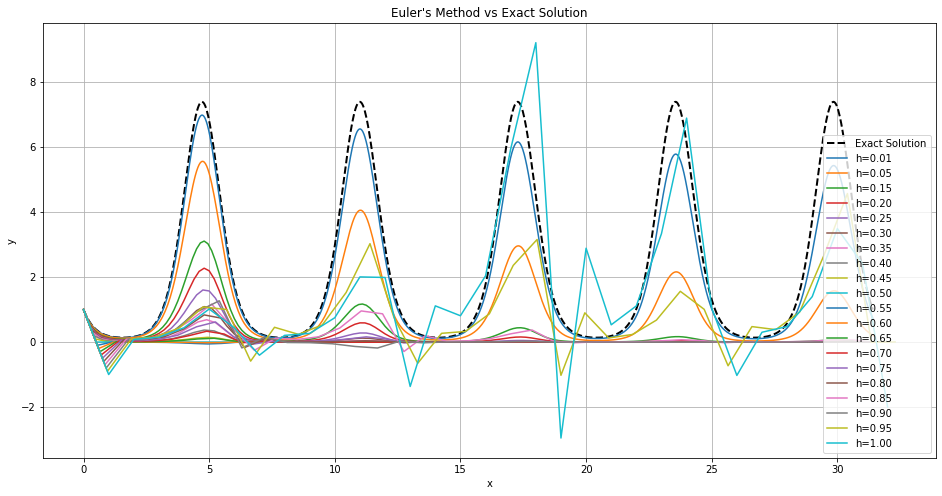

In [11]:
#Euler's Method
plt.figure(figsize=(16, 8))
x_fine = np.linspace(x_start, x_end, 1000)
plt.plot(x_fine, exact_sol(x_fine), 'k--', label='Exact Solution', linewidth=2)

for h in h_values:
    x_steps = np.arange(x_start, x_end + h, h)
    y_euler = np.zeros(len(x_steps))
    y_euler[0] = y0
    
    for i in range(len(x_steps) - 1):
        y_euler[i+1] = y_euler[i] + h * f(x_steps[i], y_euler[i])
    
    #Calculate errors
    y_true = exact_sol(x_steps)
    abs_error = np.abs(y_euler - y_true)
    
    avg_errors.append(np.mean(abs_error))
    
    #x ≈ 15
    idx_15 = (np.abs(x_steps - 15)).argmin()
    errors_at_15.append(abs_error[idx_15])
    
    plt.plot(x_steps, y_euler, label=f'h={h:.2f}')

#Euler's method for different values of h
plt.title("Euler's Method vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

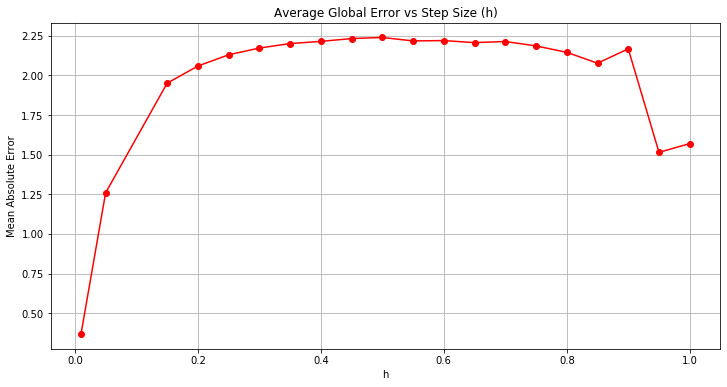

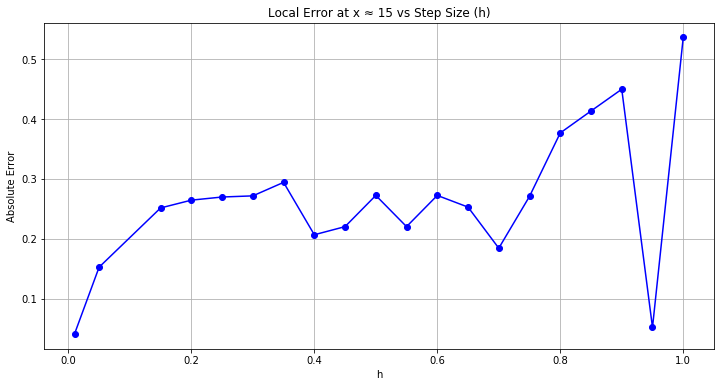

In [13]:
#Plotting Error Metrics

#Average Global Error vs h
plt.figure(figsize=(12, 6))
plt.plot(h_values, avg_errors, 'ro-', label='Avg Global Error')
plt.title("Average Global Error vs Step Size (h)")
plt.xlabel("h")
plt.ylabel("Mean Absolute Error")
plt.grid(True)

#Local Error at x ≈ 15 vs h
plt.figure(figsize=(12, 6))
plt.plot(h_values, errors_at_15, 'bo-', label='Error at x≈15')
plt.title("Local Error at x ≈ 15 vs Step Size (h)")
plt.xlabel("h")
plt.ylabel("Absolute Error")
plt.grid(True)

plt.show()

Overall, throughout all these solutions, as the step size/h increases, the approximation becomes less and less accurate. As h increases, the stability decreases. This is shown most clearly in plot 1, where the largest h values are the farthest from the original equation. The next two plots also show this trend of the approximation becoming unstable at larger and larger values of h. Both graphs show that usually, upon larger h values/step sizes, the error increases. This error in specific becomes especially unstable after around h = 0.8. This aligns with the earlier plot, where when h goes beyond 0.8, the approximation becomes increasingly eratic. 

# Addendum

We can do a stability analysis on -2*cos(x).

Just like how we idetified the error in f(x,y)=-2y, we can identify f(x,y)=-2*cos(x)'s errors, and we can see that both follow the similar trend of decreasing stability as the step-size/value of h increases. Since we have an x component now, our λ can no longer be a constant. Thus, the stiffness of our equation is also oscillating. For numerical stability, we care about the regions where the ODE is stable (where λ<0), because that is where Euler's method is prone to overshooting and oscillating wildly if the step size h is too large. Meanwhile, our λ is changing in accordance to x in the formula λ(x) = -2cos(x)

We use the formula, ∣1+hλ∣≤1, for our stability condition. If this forumla stays true, then the graph will be stable. Thus, by plugging in the worst-case scenario of when λ = −2, we can determine after distributing and expanding the equation to solve for h,that the stability condition is that h < 1.


Used AI tool, google Gemini, to check my code and understanding of this topic.